<a href="https://colab.research.google.com/github/srishtiarora42006-hue/Answer/blob/main/Logistic_Regression_(Loan_Approval_Prediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Q1.** Data Loading & Understanding

a) Load the dataset into Python.
b) Display the first 5 rows.
c) Check the shape of the dataset.
d) Display the data types of each column.

In [77]:
#loading the dataset
import pandas as pd


In [97]:
df =pd.read_excel("/content/loan_approval.xlsx")


In [79]:
# displaying first 5 rows
df.head(5)

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [80]:
#shape of the dataset
df.shape

(2000, 8)

In [81]:
#data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            2000 non-null   object
 1   city            2000 non-null   object
 2   income          2000 non-null   int64 
 3   credit_score    2000 non-null   int64 
 4   loan_amount     2000 non-null   int64 
 5   years_employed  2000 non-null   int64 
 6   points          2000 non-null   int64 
 7   loan_approved   2000 non-null   bool  
dtypes: bool(1), int64(5), object(2)
memory usage: 111.5+ KB


**Q2.** Data Cleaning

a) Check for missing values in the dataset.
b) Handle missing values appropriately.
c) Identify categorical columns present in the dataset.

In [82]:
# detecting the number of missing values
df.isnull().sum()

,0
name,0
city,0
income,0
credit_score,0
loan_amount,0
years_employed,0
points,0
loan_approved,0


as there are no missing values there will be no requirement to impute these values .

In [83]:
# identifying categorical columns
df.select_dtypes(include=['object']).columns

Index(['name', 'city'], dtype='object')

**Q3.** Exploratory Data Analysis (EDA)

a) Plot the distribution of the target variable.
b) Analyze the relationship between one numerical feature and the target variable.
c) Analyze the relationship between Years of Employment and the target variable.

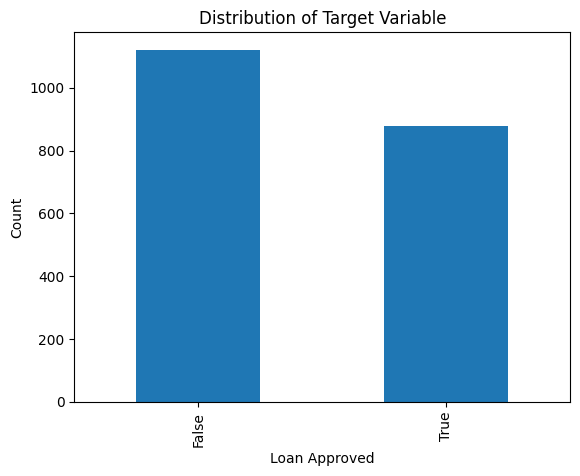

In [84]:
# distribution of target variable
X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

import matplotlib.pyplot as plt
df["loan_approved"].value_counts().plot(kind="bar")

plt.title("Distribution of Target Variable")
plt.xlabel("Loan Approved")
plt.ylabel("Count")
plt.show()


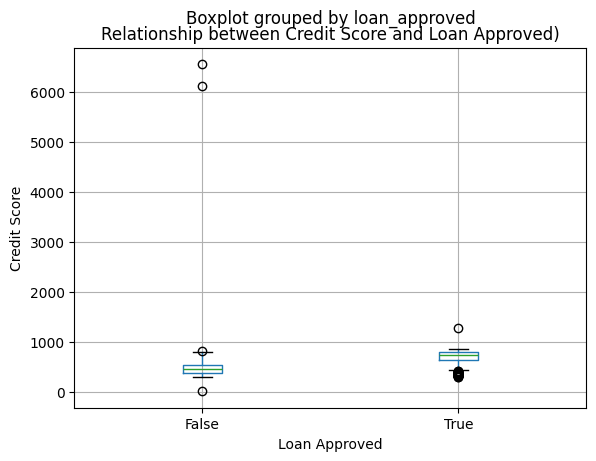

In [85]:
# relationship between a numerical variable (credit_score) and target variable (loan_approved)

df.boxplot(column="credit_score", by="loan_approved")
plt.title("Relationship between Credit Score and Loan Approved)")
plt.xlabel("Loan Approved")
plt.ylabel("Credit Score")
plt.show()

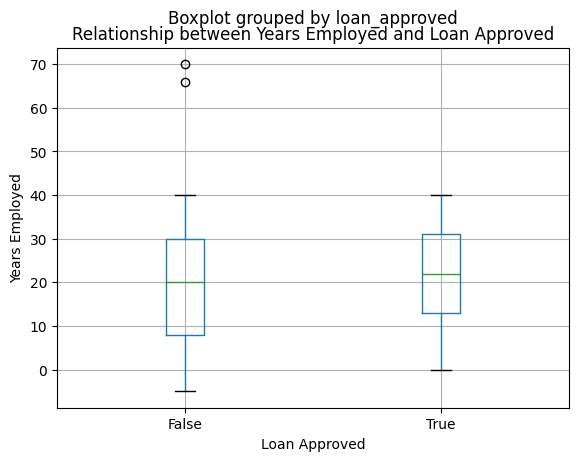

In [86]:
# relationship between years of employment and target variable("loan approved")
df.boxplot(column="years_employed", by="loan_approved")
plt.title("Relationship between Years Employed and Loan Approved")
plt.xlabel("Loan Approved")
plt.ylabel("Years Employed")
plt.show()

**Q4.** Outlier Detection and Treatment

a) Detect outliers in numerical columns using the IQR method.
b) Treat outliers using capping techniques



In [87]:
# detecting outliers in numerical columns using IQR method

numerical_cols = df.select_dtypes(include = "number").columns
print(numerical_cols)

Index(['income', 'credit_score', 'loan_amount', 'years_employed', 'points'], dtype='object')


In [88]:
from numpy._core.defchararray import lower
for col in numerical_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  print(col, ":", len(outliers), "outliers")

income : 0 outliers
credit_score : 3 outliers
loan_amount : 0 outliers
years_employed : 2 outliers
points : 0 outliers


In [89]:
# treating outliers using capping techniques
df[col] =df[col].apply(lambda x: upper_bound if x > upper_bound else x)
df[col] =df[col].apply(lambda x: lower_bound if x < lower_bound else x)

**Q5.** Convert target variables into numerical format suitable for model building and drop unnecessary columns.

In [90]:
df["loan_approved"].value_counts()


,count
loan_approved,
False,1121
True,879


In [91]:
df["loan_approved"]=df["loan_approved"].map({"Yes": 1, "No": 0})
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,NaN
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,NaN
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,NaN
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,NaN
4,Valerie Gray,Mariastad,66048,496,47174,4,25,NaN


In [92]:
df.dtypes

,0
name,object
city,object
income,int64
credit_score,int64
loan_amount,int64
years_employed,int64
points,int64
loan_approved,float64


**Q6.** Feature Selection and Data Splitting

a) Separate independent variables (X) and dependent variable (y).
b) Split the dataset into training and testing sets.

In [93]:
X = df.drop("loan_approved", axis= 1)
y =df["loan_approved"]

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2, random_state= 42)



**Q7**. Apply feature scaling to the dataset using StandardScaler.


In [100]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X = df[["income", "credit_score","loan_amount","years_employed","points"]]
y = df["loan_approved"]

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2, random_state= 42)





In [101]:

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled)
print(X_test_scaled)

[[-1.1701829  -0.44943417 -0.21763755  0.28613682 -1.67529511]
 [-0.58084238 -0.28056954 -0.20015315 -1.30846618 -1.14503355]
 [-0.05506472  0.83240188 -0.53624989  0.0343574   1.50627424]
 ...
 [-0.20062455 -0.00808343 -0.59139297 -0.04956907 -0.34964121]
 [ 1.24346696 -0.72575811 -0.87609833 -0.38527497  0.18062034]
 [ 0.26787986 -1.06348736  0.40988932 -0.21742202 -0.61477199]]
[[ 1.15775999 -0.51467732 -0.63535171 -0.88883381 -0.08451044]
 [-1.05201336  0.8707802  -1.07982336  0.0343574   1.50627424]
 [ 0.44007639  0.44861863  0.47409314  1.20932803  0.97601268]
 ...
 [ 1.00222951 -0.95986589 -1.34428363 -0.04956907  0.18062034]
 [-0.74214076  0.61748326 -0.87064773  1.37718098  1.24114346]
 [-0.75390844  0.44094296 -0.85146445  1.04147508  0.7108819 ]]


**Q8.** Logistic Regression Model Building

a) Train a Logistic Regression model.
b) Predict the output for test data.

In [98]:
df["loan_approved"] = df["loan_approved"].astype(int)

In [102]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

**Q9.** Model Evaluation – Confusion Matrix

a) Generate the confusion matrix.
b) Interpret the results

In [103]:
# generating the confusion matrix
y_pred =model.predict(X_test_scaled)
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)
print(confusion_matrix(y_test, y_pred))

[[217   0]
 [  0 183]]


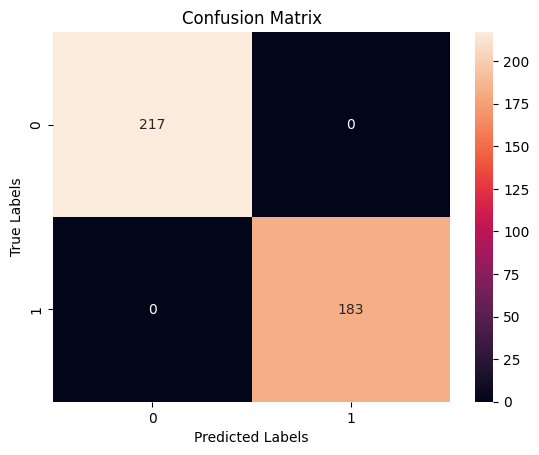

In [106]:
# visual confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

INTERPRETATION

This confusion matrix shows that: -

- 217(TN) - (True Negative) ▶ 217 applications correctly predicted as Not Approved
- 0(FP) - (False positive) ▶ 0 applications incorrectly predicted as Approved
- 0(FN) - (False Negative) ▶ 0 applications incorrectly predicted as Not Approved
- 183(TP) - (True Positive)  ▶ 183 applications correctly predicted as Approved

**Q10.** Model Evaluation – ROC Curve & AUC

a) Plot the ROC curve.
b) Calculate the AUC score.

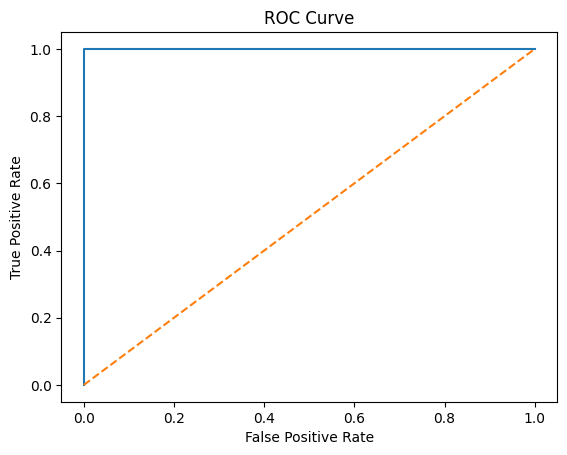

In [107]:
# plotting the ROC curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [108]:
# calculating AUC score
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 1.0
